In [2]:
import scitiff

In [3]:
ob = scitiff.load_scitiff("sample_data/Isis_data/0000030174/final/0000030174_ToFImage_2to9999.tiff")

C:\Users\christianvedel\AppData\Local\Temp\ipykernel_23232\3744541940.py:1: ImageJMetadataNotFoundWarning: ImageJ metadata not found in the tiff file.
Loading the image with arbitrary dimensions...

  ob = scitiff.load_scitiff("sample_data/Isis_data/0000030174/final/0000030174_ToFImage_2to9999.tiff")
c:\Users\christianvedel\AppData\Local\miniconda3\envs\easyimaging\Lib\site-packages\scitiff\io.py:746: IncompatibleDtypeWarning: The image data does not have compatible dtype. The image has dtype of ``uint32``. The dtype will be converted to ``<class 'numpy.int64'>``.
  image_da = sc.DataArray(data=_wrap_as_arbitrary_variable(image_values))


In [7]:
data = scitiff.load_scitiff("sample_data/Isis_data/0000030192/final/0000030192_ToFImage_2to9999.tiff")

C:\Users\christianvedel\AppData\Local\Temp\ipykernel_23232\3187524337.py:1: ImageJMetadataNotFoundWarning: ImageJ metadata not found in the tiff file.
Loading the image with arbitrary dimensions...

  data = scitiff.load_scitiff("sample_data/Isis_data/0000030192/final/0000030192_ToFImage_2to9999.tiff")


In [4]:
import scipp as sc
import numpy as np

In [ ]:
ob = ob['image'].rename_dims({'dim_2': 'x', 'dim_1': 'y', 'dim_0': 'tof'})
data = data['image'].rename_dims({'dim_2': 'x', 'dim_1': 'y', 'dim_0': 'tof'})

In [31]:
ob.coords['tof'] = sc.array(dims=['tof'], values=np.arange(0, ob.sizes['tof']*25, 25))
ob.coords['x'] = sc.array(dims=['x'], values=np.arange(1, ob.sizes['x']+1))
ob.coords['y'] = sc.array(dims=['y'], values=np.arange(1, ob.sizes['y']+1))
data.coords['tof'] = sc.array(dims=['tof'], values=np.arange(0, data.sizes['tof']*25, 25))
data.coords['x'] = sc.array(dims=['x'], values=np.arange(1, data.sizes['x']+1))
data.coords['y'] = sc.array(dims=['y'], values=np.arange(1, data.sizes['y']+1))

# Full pixel-resolution

In [32]:
ob
data

<scipp.DataArray>
Dimensions: Sizes[tof:4000, y:512, x:512, ]
Coordinates:
* tof                         int64  [dimensionless]  (tof)  [0, 25, ..., 99950, 99975]
* x                           int64  [dimensionless]  (x)  [1, 2, ..., 511, 512]
* y                           int64  [dimensionless]  (y)  [1, 2, ..., 511, 512]
Data:
                              int64  [dimensionless]  (tof, y, x)  [0, 0, ..., 0, 0]

In [49]:
lower_x = sc.scalar(40)
upper_x = sc.scalar(470)
lower_y = sc.scalar(120)
upper_y = sc.scalar(320)

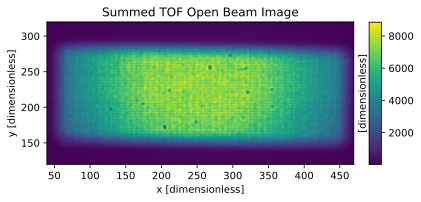

In [50]:
ob['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Summed TOF Open Beam Image")

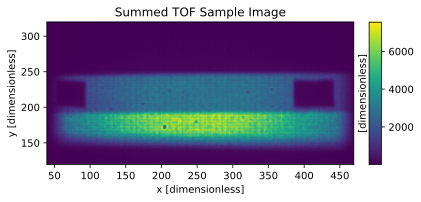

In [51]:
data['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Summed TOF Sample Image")

In [58]:
sc.Unit('microsecond')

µs

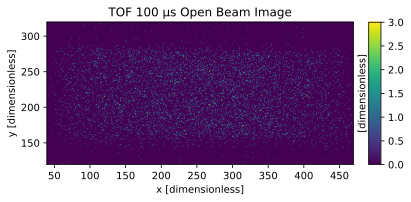

In [59]:
ob['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(100)].plot(aspect='equal', title="TOF 100 µs Open Beam Image")

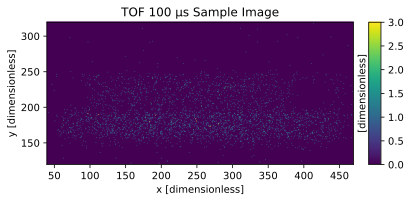

In [60]:
data['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(100)].plot(aspect='equal', title="TOF 100 µs Sample Image")

# Histogrammed in space

In [70]:
pixel_resolution = 512
tof_resolution = 1000

In [71]:
hist_ob = ob.hist(y=pixel_resolution).hist(x=pixel_resolution).hist(tof=sc.scalar(tof_resolution))
hist_ob

<scipp.DataArray>
Dimensions: Sizes[y:512, x:512, tof:100, ]
Coordinates:
* tof                         int64  [dimensionless]  (tof [bin-edge])  [0, 1000, ..., 99000, 100000]
* x                           int64  [dimensionless]  (x [bin-edge])  [1, 2, ..., 512, 513]
* y                           int64  [dimensionless]  (y [bin-edge])  [1, 2, ..., 512, 513]
Data:
                              int64  [dimensionless]  (y, x, tof)  [0, 0, ..., 0, 0]

In [72]:
hist_data = data.hist(y=pixel_resolution).hist(x=pixel_resolution).hist(tof=sc.scalar(tof_resolution))
hist_data

<scipp.DataArray>
Dimensions: Sizes[y:512, x:512, tof:100, ]
Coordinates:
* tof                         int64  [dimensionless]  (tof [bin-edge])  [0, 1000, ..., 99000, 100000]
* x                           int64  [dimensionless]  (x [bin-edge])  [1, 2, ..., 512, 513]
* y                           int64  [dimensionless]  (y [bin-edge])  [1, 2, ..., 512, 513]
Data:
                              int64  [dimensionless]  (y, x, tof)  [0, 0, ..., 0, 0]

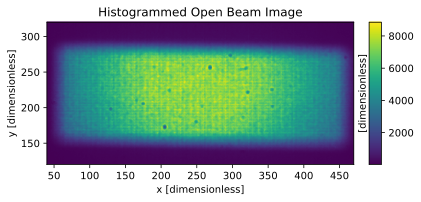

In [73]:
hist_ob['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Histogrammed Open Beam Image")

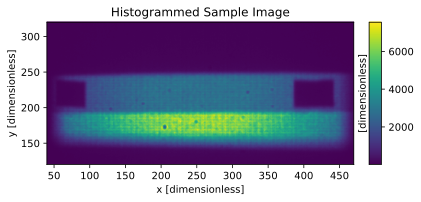

In [74]:
hist_data['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Histogrammed Sample Image")

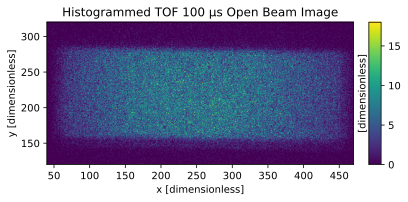

In [75]:
hist_ob['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(100)].plot(aspect='equal', title="Histogrammed TOF 100 µs Open Beam Image")

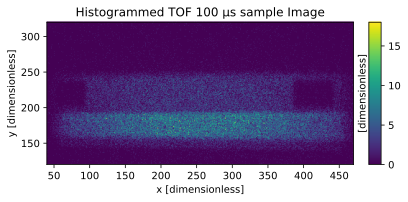

In [76]:
hist_data['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(100)].plot(aspect='equal', title="Histogrammed TOF 100 µs sample Image")

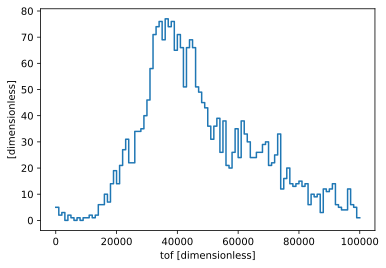

In [77]:
hist_data['x', sc.scalar(150)]['y', sc.scalar(220)].plot(linestyle='solid', marker=None)

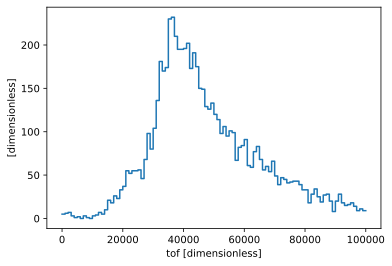

In [78]:
hist_ob['x', sc.scalar(150)]['y', sc.scalar(220)].plot(linestyle='solid', marker=None)

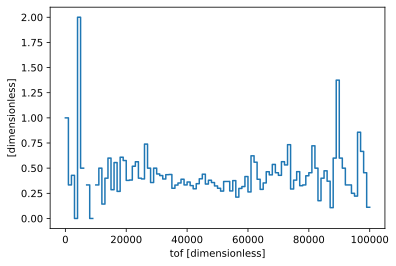

In [79]:
hist_spectrum = hist_data['x', sc.scalar(150)]['y', sc.scalar(220)]/hist_ob['x', sc.scalar(150)]['y', sc.scalar(220)]
hist_spectrum.plot(linestyle='solid', marker=None)

In [80]:
hist_spectrum

<scipp.DataArray>
Dimensions: Sizes[tof:100, ]
Coordinates:
* tof                         int64  [dimensionless]  (tof [bin-edge])  [0, 1000, ..., 99000, 100000]
  x                           int64  [dimensionless]  (x [bin-edge])  [150, 151]
  y                           int64  [dimensionless]  (y [bin-edge])  [220, 221]
Data:
                            float64  [dimensionless]  (tof)  [1, 0.333333, ..., 0.454545, 0.111111]

In [94]:
# data_first['image'].transform_coords('t', graph={'t': lambda tof, y: tof*25*sc.Unit('microsecond')})

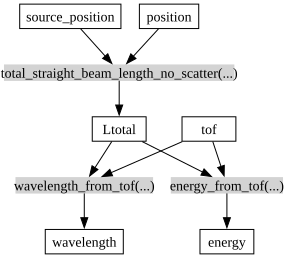

In [89]:
from scippneutron.conversion import graph


PLAIN_GRAPH = {**graph.beamline.beamline(False), **graph.tof.kinematic("tof")}

sc.show_graph(PLAIN_GRAPH)

In [90]:
PLAIN_GRAPH['Ltotal']

<function scippneutron.conversion.beamline.total_straight_beam_length_no_scatter(*, source_position: scipp._scipp.core.Variable | scipp._scipp.core.DataArray | scipp._scipp.core.Dataset | scipp.core.data_group.DataGroup[typing.Any], position: scipp._scipp.core.Variable | scipp._scipp.core.DataArray | scipp._scipp.core.Dataset | scipp.core.data_group.DataGroup[typing.Any]) -> scipp._scipp.core.Variable | scipp._scipp.core.DataArray | scipp._scipp.core.Dataset | scipp.core.data_group.DataGroup[typing.Any]>

In [ ]:
PLAIN_GRAPH['Ltotal'] = sc.scalar(56.5, unit='m')

In [ ]:
def wav